In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import joblib

print("1. Loading cleaned data...")
data = pd.read_csv("cleaned_data.csv")
print(f"Data shape: {data.shape}")

1. Loading cleaned data...
Data shape: (262755, 31)


In [10]:
X = data.drop(columns='Class')
Y = data['Class']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print("Training class distribution:")
print(Y_train.value_counts())

print("\nTesting class distribution:")
print(Y_test.value_counts())

print(f"Original Training data shape: {X_train.shape}")
print(f"Test data shape (Untouched): {X_test.shape}")

Training class distribution:
Class
0    209810
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    52453
1       98
Name: count, dtype: int64
Original Training data shape: (210204, 30)
Test data shape (Untouched): (52551, 30)


In [11]:
print("3. Applying SMOTE on Training Data...")

smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_smote, Y_train_smote = smote.fit_resample(
    X_train,
    Y_train
)

print("Training data shape AFTER SMOTE:", X_train_smote.shape)
print("\nClass distribution AFTER SMOTE:")
print(Y_train_smote.value_counts())

3. Applying SMOTE on Training Data...
Training data shape AFTER SMOTE: (419620, 30)

Class distribution AFTER SMOTE:
Class
0    209810
1    209810
Name: count, dtype: int64


In [12]:
from xgboost import XGBClassifier

# Initialize Models (Ab 4 models test honge!)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

best_model_name = ""
best_model = None
best_score = 0

print("--- Starting Model Training ---")
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model on the SMOTE balanced training data
    model.fit(X_train_smote, Y_train_smote)

    # Predict on the UNTOUCHED Test data
    y_pred = model.predict(X_test)

    # Evaluate using F1-Score (Best for Imbalanced Data)
    f1 = f1_score(Y_test, y_pred)
    acc = accuracy_score(Y_test, y_pred)

    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

    # Select the model with the highest F1-Score
    if f1 > best_score:
        best_score = f1
        best_model = model
        best_model_name = name

print("\n" + "="*40)
print(f"🏆 BEST MODEL SELECTED: {best_model_name} with F1-Score: {best_score:.4f}")
print("="*40)

--- Starting Model Training ---

Training Logistic Regression...
Accuracy: 0.9803 | F1-Score: 0.1380

Training Decision Tree...
Accuracy: 0.9982 | F1-Score: 0.6091

Training Random Forest...
Accuracy: 0.9994 | F1-Score: 0.8415

Training XGBoost...
Accuracy: 0.9993 | F1-Score: 0.8223

🏆 BEST MODEL SELECTED: Random Forest with F1-Score: 0.8415


In [13]:
print("="*40)
print(f"🏆 BEST MODEL SELECTED: {best_model_name}")
print(f"🏆 BEST F1-SCORE: {best_score:.4f}")
print("="*40)

# Save the Best Model
joblib.dump(best_model, 'best__fraud_model.pkl')
print("Model saved successfully as 'best_fraud_model.pkl' for Deployment!")

🏆 BEST MODEL SELECTED: Random Forest
🏆 BEST F1-SCORE: 0.8415
Model saved successfully as 'best_fraud_model.pkl' for Deployment!


--- Deep Evaluation for Random Forest ---

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52453
           1       0.91      0.79      0.84        98

    accuracy                           1.00     52551
   macro avg       0.95      0.89      0.92     52551
weighted avg       1.00      1.00      1.00     52551


Generating Confusion Matrix...


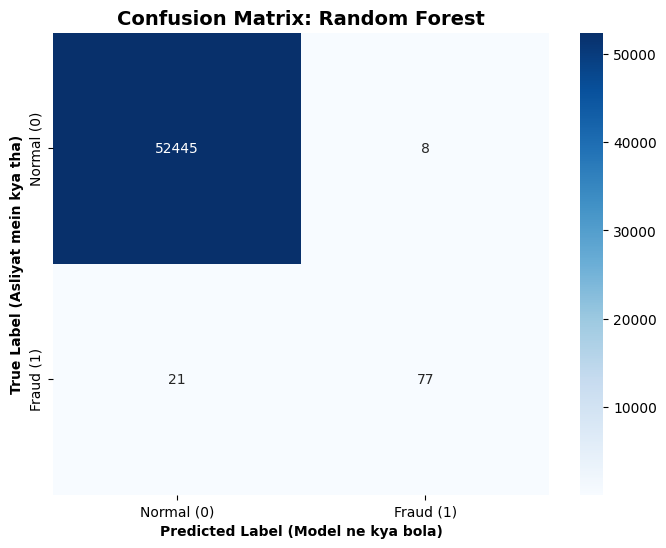

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print(f"--- Deep Evaluation for {best_model_name} ---")

# 1. Detailed Classification Report
print("\nClassification Report:\n")
y_pred_best = best_model.predict(X_test)
print(classification_report(Y_test, y_pred_best))

# 2. Confusion Matrix Visualization
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(Y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title(f'Confusion Matrix: {best_model_name}', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label (Model ne kya bola)', fontweight='bold')
plt.ylabel('True Label (Asliyat mein kya tha)', fontweight='bold')
plt.show()

In [16]:
import joblib
import pandas as pd
import numpy as np

print("--- Running Prediction Script ---")

# 1. Load the saved model
loaded_model = joblib.load('best__fraud_model.pkl')
print("Model Loaded Successfully!\n")

# 2. Pick a random transaction from the test data to simulate real-world input
sample_index = X_test.sample(1, random_state=99).index[0]
sample_transaction = X_test.loc[[sample_index]]
actual_label = Y_test.loc[sample_index]

# 3. Make Prediction
prediction = loaded_model.predict(sample_transaction)
# Getting the probability of the transaction being Fraud (Class 1)
prediction_prob = loaded_model.predict_proba(sample_transaction)[0][1] * 100

print(f"🔍 Testing Transaction Index: {sample_index}")
print("-" * 35)
print(f"(Actual Class) : {'Fraud ' if actual_label == 1 else 'Normal '}")
print(f"Answer of Model        : {'Fraud ' if prediction[0] == 1 else 'Normal '}")
print(f"Fraud Probability      : {prediction_prob:.2f}%")
print("-" * 35)

if actual_label == prediction[0]:
    print(" Result: Model is CORRECT!")
else:
    print(" Result: Model is WRONG!")

--- Running Prediction Script ---
Model Loaded Successfully!

🔍 Testing Transaction Index: 262705
-----------------------------------
(Actual Class) : Fraud 
Answer of Model        : Fraud 
Fraud Probability      : 99.00%
-----------------------------------
 Result: Model is CORRECT!


In [17]:
fraud_indices = data[data['Class'] == 1].index

print(fraud_indices[:10].tolist())

[262263, 262264, 262265, 262266, 262267, 262268, 262269, 262270, 262271, 262272]
